# 04 – Neural Network: Exercise Recognition

Dieses Notebook trainiert ein **Multilayer Perceptron (MLP)** auf den handgefertigten Features aus `03_Features` (ML_Module_Project).

---

## Warum MLP und nicht CNN/LSTM?

| Architektur | Wann sinnvoll | Hier? |
|---|---|---|
| **MLP** | Tabellarische Feature-Vektoren (mean, std, fft, …) | ✅ |
| CNN (1D) | Rohe Zeitreihenfenster direkt | ❌ (wäre Option 2, aber braucht PREPROC_DF) |
| LSTM/GRU | Sequenzen mit langer zeitl. Abhängigkeit | ❌ (Features sind bereits aggregiert) |

Da wir **aggregierte Features** (Mean, Std, FFT, Peak-Mittel) als Input haben und keinen rohen Zeitsignalstrom,  
ist ein MLP die natürlichste und effizienteste Wahl.

## Warum welche Activation Functions?

- **ReLU** in den Hidden Layers: Standard für tiefe Netze. Kein Vanishing-Gradient-Problem, rechnerisch günstig, konvergiert schnell.
- **Softmax** im Output Layer: Wir haben 35 Klassen (Mehrklassen-Klassifikation). Softmax wandelt die Rohausgaben in Wahrscheinlichkeiten um, die sich zu 1 summieren.  
  → Kombiniert mit `CrossEntropyLoss` in PyTorch (das intern Softmax + Log einbaut).
- **BatchNorm** nach jeder ReLU: Stabilisiert das Training, erlaubt höhere Lernraten.
- **Dropout** (p=0.3): Regularisierung gegen Overfitting – wichtig, da manche Klassen nur 2–130 Samples haben.

---

## Ordnerstruktur
```
ML_Module_Project/      ← bestehende Daten (read-only)
    features.pkl
    exercise_dict.pkl

NN_Module_Project/      ← dieses Projekt
    04_Neural_Network.ipynb   ← dieses File
    models/             ← wird automatisch erstellt
        best_model.pt
```

## 0 – Setup & Imports

In [1]:
# ── Zelle 1: Google Drive mounten ────────────────────────────────────────────
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ── Standard-Bibliotheken ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── Scikit-learn (Preprocessing, Evaluation) ──────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

print(f"PyTorch Version : {torch.__version__}")
print(f"CUDA verfügbar  : {torch.cuda.is_available()}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Gerät           : {DEVICE}")

PyTorch Version : 2.10.0+cpu
CUDA verfügbar  : False
Gerät           : cpu


In [3]:
from pathlib import Path
import os
print(Path.cwd())
print(os.listdir(Path.cwd()))

/content
['.config', 'drive', 'sample_data']


In [4]:
# ── Zelle 2: Pfade setzen & Dateien prüfen ───────────────────────────────────
# Drive-Ordner-ID aus deinem Link: 1y1en1SII7waBI4IjZagmqK48a_bauQRa
# Der Ordner liegt unter MyDrive – Pfad via ID direkt ansprechen

ML_PROJECT = Path('/content/drive/My Drive/NN_Project')

# Falls der obige Pfad nicht stimmt (Ordner in einem Unterordner),
# suchen wir automatisch anhand der Drive-ID:
if not ML_PROJECT.exists():
    import subprocess
    result = subprocess.run(
        ['find', '/content/drive', '-name', 'features.pkl'],
        capture_output=True, text=True
    )
    found = result.stdout.strip()
    if found:
        ML_PROJECT = Path(found).parent
        print(f"Gefunden unter: {ML_PROJECT}")
    else:
        print("Nicht gefunden – prüfe ob Drive korrekt gemountet ist")

MODEL_DIR = Path('/content/drive/My Drive/NN_Project/models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ── Dateien prüfen ────────────────────────────────────────────────────────────
DATA_FILES = {
    'features'        : ML_PROJECT / 'features.pkl',
    'exercise_dict'   : ML_PROJECT / 'exercise_dict.pkl',
    'labeled_250ms'   : ML_PROJECT / '250MS_labeled.pkl',
    'resampled_250ms' : ML_PROJECT / '250MS_Resampled.pkl',
}

for name, path in DATA_FILES.items():
    assert path.exists(), f"{path.name} nicht gefunden unter {path}"
    print(f"  ✓ {path.name}")

print(f"\n✓ Alle {len(DATA_FILES)} Dateien gefunden.")
print(f"  ML-Daten : {ML_PROJECT}")
print(f"  Modelle  : {MODEL_DIR}")

  ✓ features.pkl
  ✓ exercise_dict.pkl
  ✓ 250MS_labeled.pkl
  ✓ 250MS_Resampled.pkl

✓ Alle 4 Dateien gefunden.
  ML-Daten : /content/drive/My Drive/NN_Project
  Modelle  : /content/drive/My Drive/NN_Project/models


## 1 – Daten laden & bereinigen

In [5]:
# ── Rohdaten einlesen ─────────────────────────────────────────────────────────
Feature_DF  = pd.read_pickle(DATA_FILES['features'])
EXERCISE_DF = pd.read_pickle(DATA_FILES['exercise_dict'])

# Mapping: Integer-Klasse → Übungsname
exercise_map = dict(zip(EXERCISE_DF['key'], EXERCISE_DF['value']))

print(f"Feature_DF Shape : {Feature_DF.shape}")
print(f"Klassen          : {sorted(Feature_DF['target'].dropna().unique().astype(int))}")
print(f"\nTarget-Verteilung:")
print(Feature_DF['target'].value_counts(dropna=False).head(10))

Feature_DF Shape : (8978, 103)
Klassen          : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(14), np.int64(16), np.int64(17), np.int64(19), np.int64(20), np.int64(21), np.int64(23), np.int64(24), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34)]

Target-Verteilung:
target
0.0     4564
1.0     2167
7.0      255
2.0      251
24.0     130
11.0     127
17.0     111
3.0      107
21.0     107
26.0     102
Name: count, dtype: int64


In [6]:
# ── Nur gelabelte Fenster behalten (NaN-Target = kein Ground Truth) ───────────
df_labeled = Feature_DF.dropna(subset=['target']).copy()
df_labeled['target'] = df_labeled['target'].astype(int)

print(f"Gelabelte Fenster : {len(df_labeled)}")
print(f"Unlabeled (NaN)   : {len(Feature_DF) - len(df_labeled)}")

# ── Feature-Spalten = alle ausser target, target_name, datetime ───────────────
feature_cols = [c for c in df_labeled.columns if c not in ('target', 'target_name', 'datetime')]
print(f"\nAnzahl Features   : {len(feature_cols)}")
print(f"Beispiel-Features : {feature_cols[:6]}")

Gelabelte Fenster : 8937
Unlabeled (NaN)   : 41

Anzahl Features   : 100
Beispiel-Features : ['mean_HR_bpm', 'std_HR_bpm', 'fft_HR_bpm', 'mean_peak_HR_bpm', 'mean_val_HR_bpm', 'mean_ACC_z']


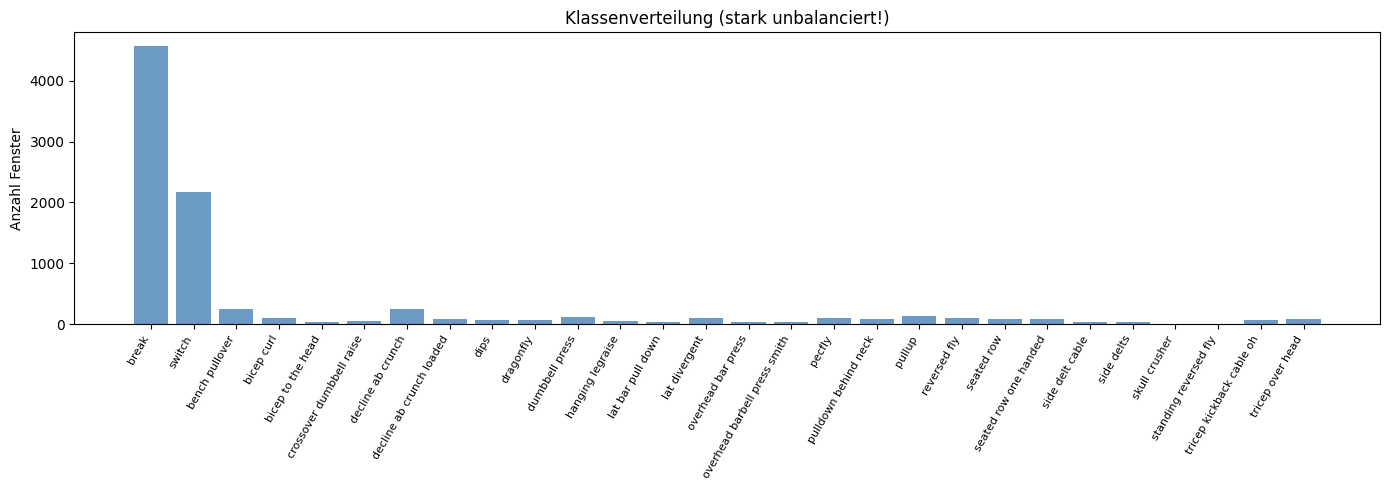

In [7]:
# ── Klassenverteilung visualisieren ───────────────────────────────────────────
# WICHTIG: Die Daten sind stark unbalanciert (break/switch >> Übungen)
# Das Netz würde sonst bias Richtung Mehrheitsklassen entwickeln.

counts = df_labeled['target'].value_counts().sort_index()
labels = [exercise_map.get(i, str(i)) for i in counts.index]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(counts)), counts.values, color='steelblue', alpha=0.8)
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(labels, rotation=60, ha='right', fontsize=8)
ax.set_ylabel('Anzahl Fenster')
ax.set_title('Klassenverteilung (stark unbalanciert!)')
plt.tight_layout()
plt.show()

## 2 – Preprocessing: Skalierung & Train/Val/Test-Split

In [8]:
X = df_labeled[feature_cols].values.astype(np.float32)
y = df_labeled['target'].values

# ── Klassen mit weniger als 5 Samples entfernen ───────────────────────────────
# stratify braucht mindestens 2 Samples pro Klasse in JEDEM Split
# Bei 70/15/15 bedeutet das: mindestens ~5 Samples total pro Klasse
EXCLUDE_CLASSES = {0, 1}  # 0=break, 1=switch
min_samples = 5
class_counts = pd.Series(y).value_counts()
valid_classes = [c for c in class_counts[class_counts >= min_samples].index
                 if c not in EXCLUDE_CLASSES]
mask = pd.Series(y).isin(valid_classes).values

X = X[mask]
y = y[mask]

removed = class_counts[class_counts < min_samples]
print(f"Entfernte Klassen ({len(removed)}):")
for cls, cnt in removed.items():
    print(f"  {exercise_map.get(int(cls), str(cls)):30s} → {cnt} Sample(s)")

# ── Label-Encoding ────────────────────────────────────────────────────────────
le = LabelEncoder()
y_enc = le.fit_transform(y)
N_CLASSES = len(le.classes_)
print(f"\nAnzahl Klassen nach Encoding : {N_CLASSES}")

# ── 70% Train / 15% Val / 15% Test ───────────────────────────────────────────
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y_enc, test_size=0.30, random_state=42, stratify=y_enc
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp
)

print(f"\nTrain : {X_train.shape[0]:>5} Samples")
print(f"Val   : {X_val.shape[0]:>5} Samples")
print(f"Test  : {X_test.shape[0]:>5} Samples")

Entfernte Klassen (2):
  skull crusher                  → 4 Sample(s)
  standing reversed fly          → 2 Sample(s)

Anzahl Klassen nach Encoding : 24

Train :  1540 Samples
Val   :   330 Samples
Test  :   330 Samples


In [9]:
# ── StandardScaler: Fit NUR auf Trainingsdaten! ───────────────────────────────
# Wichtig: val/test werden nur transformiert (kein re-fit)
# → verhindert Data Leakage

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

# NaN-Werte auffüllen (können durch std=0 Features entstehen)
X_train_s = np.nan_to_num(X_train_s, nan=0.0)
X_val_s   = np.nan_to_num(X_val_s,   nan=0.0)
X_test_s  = np.nan_to_num(X_test_s,  nan=0.0)

N_FEATURES = X_train_s.shape[1]
print(f"Feature-Dimension : {N_FEATURES}")

Feature-Dimension : 100


## 3 – Klassenungleichgewicht behandeln

Zwei komplementäre Strategien:
1. **`class_weight`** im Loss-Funktion: seltene Klassen werden stärker bestraft wenn falsch klassifiziert
2. **`WeightedRandomSampler`** im DataLoader: seltenere Klassen werden im Mini-Batch häufiger gezogen

In [10]:
# ── Klassen-Gewichte für den Loss ─────────────────────────────────────────────
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(N_CLASSES),
    y=y_train
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(DEVICE)
print("Class weights (erste 10):", class_weights_np[:10].round(2))

# ── WeightedRandomSampler: jede Klasse gleich häufig im Batch ─────────────────
sample_weights = class_weights_np[y_train]  # Gewicht pro Sample
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

Class weights (erste 10): [0.36 0.86 2.21 1.6  0.36 1.07 1.17 1.19 0.72 1.89]


## 4 – PyTorch Dataset & DataLoader

In [11]:
class ExerciseDataset(Dataset):
    """Simples Dataset: wandelt numpy-Arrays in PyTorch-Tensoren."""

    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ── DataLoader Konfiguration ─────────────────────────────────────────────────
BATCH_SIZE = 64

train_loader = DataLoader(
    ExerciseDataset(X_train_s, y_train),
    batch_size=BATCH_SIZE,
    sampler=sampler,      # WeightedRandomSampler statt shuffle=True
    drop_last=True        # letzten unvollständigen Batch verwerfen (stabiler)
)
val_loader = DataLoader(
    ExerciseDataset(X_val_s, y_val),
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_loader = DataLoader(
    ExerciseDataset(X_test_s, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Train-Batches : {len(train_loader)}")
print(f"Val-Batches   : {len(val_loader)}")

Train-Batches : 24
Val-Batches   : 6


## 5 – Modell-Definition: MLP

### Architektur-Entscheidungen

```
Input (~100 Features)
    │
    ▼
Linear(100 → 256)  + BatchNorm + ReLU + Dropout(0.3)
    │
Linear(256 → 256)  + BatchNorm + ReLU + Dropout(0.3)
    │
Linear(256 → 128)  + BatchNorm + ReLU + Dropout(0.2)
    │
Linear(128 → N_CLASSES)   ← Logits (kein Softmax hier, da CrossEntropyLoss)
```

**ReLU** (Rectified Linear Unit) als Aktivierungsfunktion in den Hidden Layers:
- `max(0, x)` – einfach und effektiv
- Kein Vanishing-Gradient-Problem wie bei Sigmoid/Tanh
- De-facto Standard für MLPs und CNNs

**Softmax** ist im `CrossEntropyLoss` von PyTorch eingebaut – daher KEIN expliziter Softmax-Layer.

In [12]:
class ExerciseMLP(nn.Module):
    """
    Multilayer Perceptron für Mehrklassen-Klassifikation von Fitness-Übungen.

    Aufbau: Linear → BatchNorm → ReLU → Dropout (x3), dann Output-Linear
    """

    def __init__(self, n_features: int, n_classes: int, hidden: list[int] = [256, 256, 128]):
        super().__init__()

        layers = []
        in_dim = n_features
        dropouts = [0.5, 0.4]  # abnehmendes Dropout in tieferen Schichten

        for out_dim, drop in zip(hidden, dropouts):
            layers += [
                nn.Linear(in_dim, out_dim),
                nn.BatchNorm1d(out_dim),  # stabilisiert Training
                nn.ReLU(),                # Aktivierungsfunktion
                nn.Dropout(p=drop)        # Regularisierung
            ]
            in_dim = out_dim

        layers.append(nn.Linear(in_dim, n_classes))  # Output: Logits

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


# ── Modell initialisieren ─────────────────────────────────────────────────────
model = ExerciseMLP(n_features=N_FEATURES, n_classes=N_CLASSES).to(DEVICE)
print(model)

# Anzahl trainierbare Parameter
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainierbare Parameter: {n_params:,}")

ExerciseMLP(
  (network): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=256, out_features=24, bias=True)
  )
)

Trainierbare Parameter: 98,840


## 6 – Training

In [13]:
# ── Loss & Optimizer ──────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=10, factor=0.5
)

# ── Hilfsfunktionen ───────────────────────────────────────────────────────────
def run_epoch(loader, train=True):
    """Führt eine Trainings- oder Evaluierungs-Epoche durch."""
    model.train(train)

    total_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(train):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

            logits = model(X_batch)
            loss   = criterion(logits, y_batch)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(dim=1) == y_batch).sum().item()
            total      += len(y_batch)

    return total_loss / total, correct / total

In [14]:
# ── Trainings-Loop ────────────────────────────────────────────────────────────
N_EPOCHS      = 100
PATIENCE      = 20     # Early Stopping: Abbrechen wenn kein Fortschritt
best_val_loss = float('inf')
patience_counter = 0

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, N_EPOCHS + 1):

    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss,   val_acc   = run_epoch(val_loader,   train=False)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # ── Bestes Modell speichern ───────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_DIR / 'best_model.pt')
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoche {epoch:>3}/{N_EPOCHS}  "
              f"Train-Loss: {train_loss:.4f}  Train-Acc: {train_acc:.3f}  "
              f"Val-Loss: {val_loss:.4f}  Val-Acc: {val_acc:.3f}")

    # ── Early Stopping ────────────────────────────────────────────────────────
    if patience_counter >= PATIENCE:
        print(f"\n→ Early Stopping nach Epoche {epoch} (kein Fortschritt seit {PATIENCE} Epochen)")
        break

print(f"\n✓ Bestes Modell gespeichert: Val-Loss = {best_val_loss:.4f}")

Epoche   1/100  Train-Loss: 2.3115  Train-Acc: 0.329  Val-Loss: 1.9135  Val-Acc: 0.403
Epoche  10/100  Train-Loss: 0.3488  Train-Acc: 0.867  Val-Loss: 0.4281  Val-Acc: 0.882
Epoche  20/100  Train-Loss: 0.1668  Train-Acc: 0.940  Val-Loss: 0.3053  Val-Acc: 0.915
Epoche  30/100  Train-Loss: 0.1180  Train-Acc: 0.946  Val-Loss: 0.2950  Val-Acc: 0.915
Epoche  40/100  Train-Loss: 0.0931  Train-Acc: 0.963  Val-Loss: 0.2848  Val-Acc: 0.930
Epoche  50/100  Train-Loss: 0.0607  Train-Acc: 0.974  Val-Loss: 0.2778  Val-Acc: 0.948
Epoche  60/100  Train-Loss: 0.0479  Train-Acc: 0.983  Val-Loss: 0.2699  Val-Acc: 0.952
Epoche  70/100  Train-Loss: 0.0551  Train-Acc: 0.978  Val-Loss: 0.2739  Val-Acc: 0.952

→ Early Stopping nach Epoche 75 (kein Fortschritt seit 20 Epochen)

✓ Bestes Modell gespeichert: Val-Loss = 0.2499


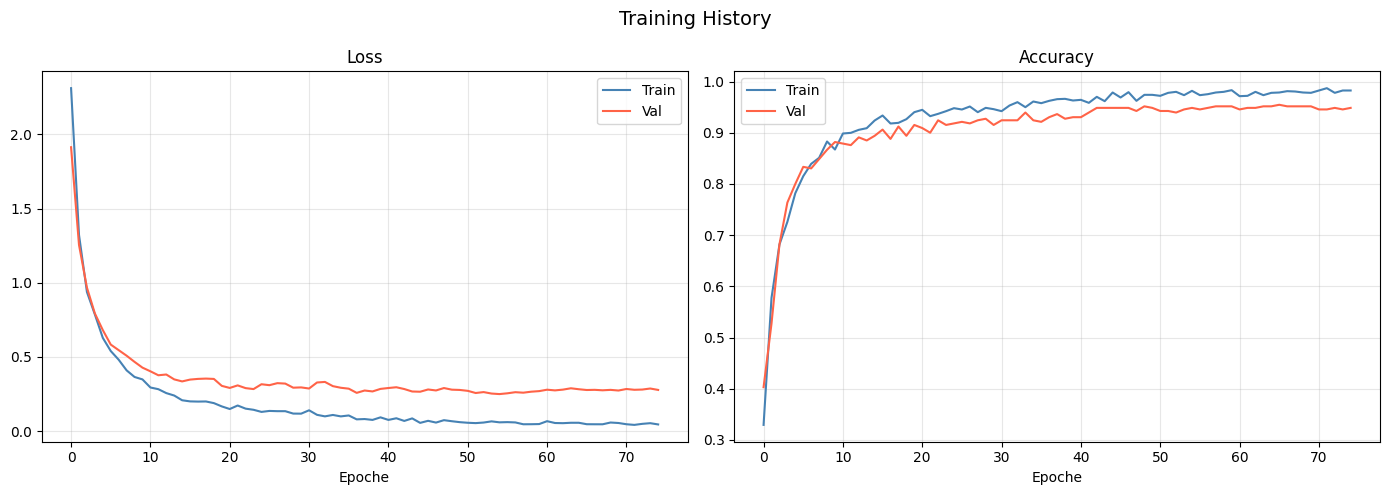

In [15]:
# ── Loss- und Accuracy-Kurven ─────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train', color='steelblue')
ax1.plot(history['val_loss'],   label='Val',   color='tomato')
ax1.set_title('Loss')
ax1.set_xlabel('Epoche')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history['train_acc'], label='Train', color='steelblue')
ax2.plot(history['val_acc'],   label='Val',   color='tomato')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoche')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Training History', fontsize=14)
plt.tight_layout()
plt.show()

## 7 – Evaluation auf dem Test-Set

In [16]:
# ── Bestes Modell laden ───────────────────────────────────────────────────────
model.load_state_dict(torch.load(MODEL_DIR / 'best_model.pt', map_location=DEVICE))
model.eval()

# ── Predictions auf dem Test-Set sammeln ─────────────────────────────────────
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        preds   = model(X_batch).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# ── Labels zurück-übersetzen (encoded → original IDs → Namen) ─────────────────
original_ids   = le.inverse_transform(np.arange(N_CLASSES))
class_names    = [exercise_map.get(int(i), str(i)) for i in original_ids]

# Nur Klassen die im Test-Set vorkommen (sonst Fehler in classification_report)
present = np.unique(all_labels)
present_names = [class_names[i] for i in present]

print("=" * 70)
print(classification_report(
    all_labels, all_preds,
    labels=present,
    target_names=present_names
))
print("=" * 70)

                              precision    recall  f1-score   support

              bench pullover       0.95      0.97      0.96        37
                  bicep curl       1.00      0.94      0.97        16
           bicep to the head       1.00      1.00      1.00         7
    crossover dumbbell raise       1.00      1.00      1.00         9
           decline ab crunch       0.97      0.97      0.97        38
    decline ab crunch loaded       0.85      0.85      0.85        13
                        dips       1.00      1.00      1.00        11
                   dragonfly       0.92      0.92      0.92        12
              dumbbell press       0.94      0.84      0.89        19
            hanging legraise       1.00      1.00      1.00         7
           lat bar pull down       1.00      1.00      1.00         7
               lat divergent       0.89      1.00      0.94        16
          overhead bar press       1.00      1.00      1.00         5
overhead barbell pr

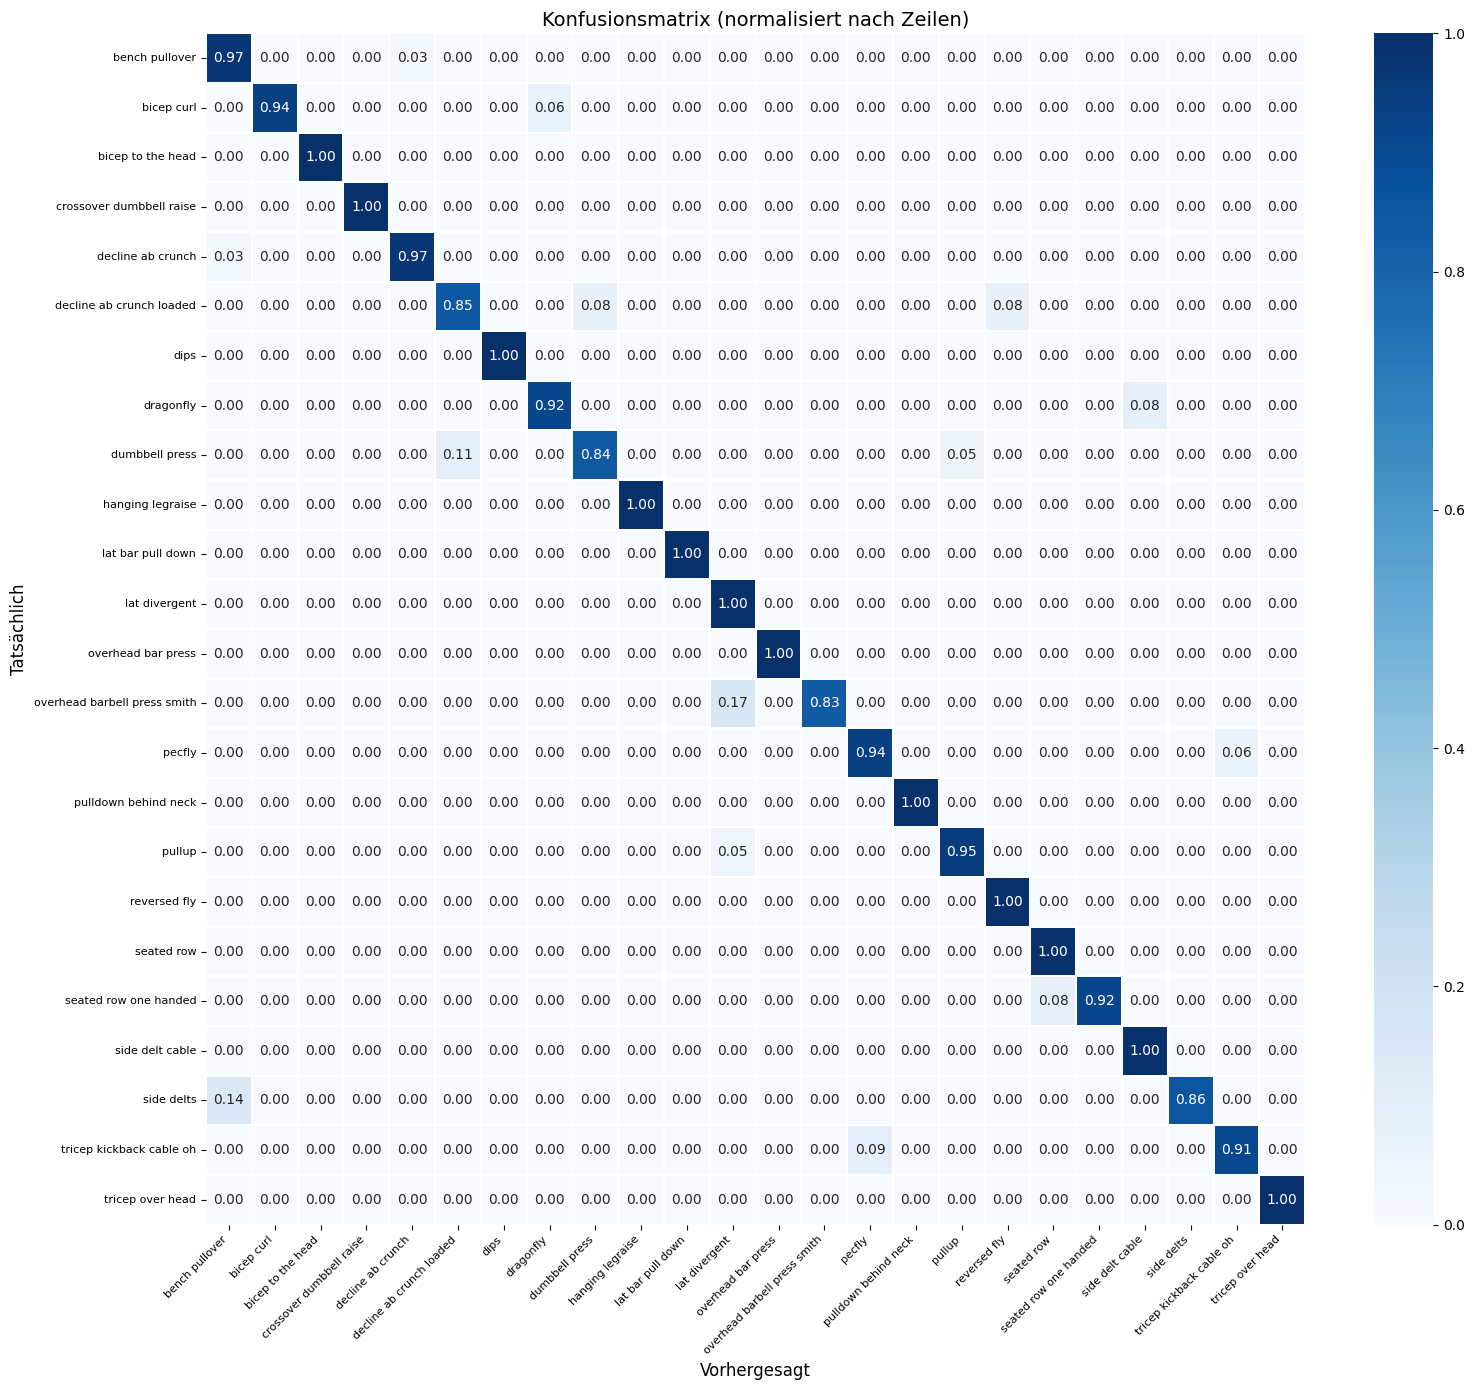

In [17]:
# ── Konfusionsmatrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds, labels=present, normalize='true')

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=present_names, yticklabels=present_names,
    linewidths=0.3, ax=ax
)
ax.set_xlabel('Vorhergesagt', fontsize=12)
ax.set_ylabel('Tatsächlich',  fontsize=12)
ax.set_title('Konfusionsmatrix (normalisiert nach Zeilen)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.show()

## 8 – Inference: Einzelne Vorhersage

In [18]:
def predict_exercise(feature_vector: np.ndarray, top_k: int = 3):
    """
    Vorhersage für einen einzelnen Feature-Vektor.

    Parameters:
        feature_vector : numpy-Array der Länge N_FEATURES (ungeskaliert, wie aus Feature_DF)
        top_k          : wie viele Top-Kandidaten anzeigen

    Returns:
        dict mit predicted_class, confidence, top_k_predictions
    """
    model.eval()

    # Skalieren (gleicher Scaler wie beim Training!)
    x_scaled = scaler.transform(feature_vector.reshape(1, -1)).astype(np.float32)
    x_scaled = np.nan_to_num(x_scaled, nan=0.0)
    x_tensor = torch.tensor(x_scaled).to(DEVICE)

    with torch.no_grad():
        logits = model(x_tensor)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]

    top_indices = probs.argsort()[::-1][:top_k]
    top_classes = le.inverse_transform(top_indices)  # encoded → original ID

    return {
        'predicted_class' : exercise_map.get(int(top_classes[0]), 'unknown'),
        'confidence'      : float(probs[top_indices[0]]),
        'top_k'           : [
            {'class': exercise_map.get(int(c), str(c)), 'prob': float(probs[i])}
            for c, i in zip(top_classes, top_indices)
        ]
    }


# ── Beispiel: Erstes Sample aus dem Test-Set ──────────────────────────────────
sample_features = X_test[0]  # ungeskalierter Feature-Vektor
true_label      = exercise_map.get(int(le.inverse_transform([y_test[0]])[0]), 'unknown')

result = predict_exercise(sample_features, top_k=3)

print(f"Tatsächliche Klasse : {true_label}")
print(f"Vorhergesagt        : {result['predicted_class']} ({result['confidence']:.1%} Konfidenz)")
print(f"\nTop-3 Kandidaten:")
for entry in result['top_k']:
    print(f"  {entry['class']:35s}  {entry['prob']:.1%}")

Tatsächliche Klasse : pecfly
Vorhergesagt        : pecfly (99.9% Konfidenz)

Top-3 Kandidaten:
  pecfly                               99.9%
  seated row                           0.1%
  pulldown behind neck                 0.0%


## 9 – Modell & Scaler exportieren (für Deployment)

In [19]:
import pickle

# ── Scaler und Label-Encoder speichern ────────────────────────────────────────
# Wird für Inference auf neuen Daten benötigt
with open(MODEL_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open(MODEL_DIR / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# ── Modell-Konfiguration speichern (zum späteren Laden) ───────────────────────
model_config = {
    'n_features' : N_FEATURES,
    'n_classes'  : N_CLASSES,
    'hidden'     : [128, 64],
    'feature_cols': feature_cols,
    'class_names': class_names
}
with open(MODEL_DIR / 'model_config.pkl', 'wb') as f:
    pickle.dump(model_config, f)

print("✓ Gespeichert:")
for f in MODEL_DIR.iterdir():
    print(f"  {f.name}")

✓ Gespeichert:
  best_model.pt
  model_config.pkl
  label_encoder.pkl
  scaler.pkl


In [21]:
# ── Notebook als HTML exportieren → erst wenn Evaluation fertig ───────────────
import subprocess

# Sicherheitscheck: Export nur wenn Evaluation bereits gelaufen ist
assert 'all_preds' in dir(), "⚠️ Erst Zelle 7 (Evaluation) ausführen!"
assert 'result' in dir(),    "⚠️ Erst Zelle 8 (Inference) ausführen!"

NB_NAME     = '04_Neural_Network.ipynb'
NB_PATH     = Path('/content/drive/My Drive/NN_Project') / NB_NAME
OUTPUT_PATH = NB_PATH.with_suffix('.html')

# Notebook speichern bevor Export
import time
time.sleep(2)  # kurz warten damit Drive-Sync abgeschlossen ist

result_export = subprocess.run(
    ['jupyter', 'nbconvert', '--to', 'html', str(NB_PATH), '--output', str(OUTPUT_PATH)],
    capture_output=True, text=True
)

if result_export.returncode == 0:
    print(f"✓ HTML gespeichert: {OUTPUT_PATH}")
else:
    print(f"Fehler: {result_export.stderr}")

✓ HTML gespeichert: /content/drive/My Drive/NN_Project/04_Neural_Network.html
